
# Direction R: Leave-one-drug-out genome–drug generalization

Mô phỏng tình huống **gặp thuốc mới**.

Ý tưởng:

> Train model trên 4 thuốc đã biết, sau đó test trên thuốc còn lại như một thuốc mới chưa từng xuất hiện trong training.


- Không dùng `drug ID one-hot` làm feature chính, vì thuốc mới sẽ không có ID trong train.
- Dùng **đặc trưng gen phụ của mẫu** + **đặc trưng hóa học/nhóm thuốc của kháng sinh**.
- So sánh nhiều setting:
  1. `genome_only`: chỉ dùng gen phụ.
  2. `chemical_only`: chỉ dùng đặc trưng thuốc.
  3. `genome_plus_chemical`: gen phụ + đặc trưng hóa học/nhóm thuốc.
  4. `genome_plus_class_flags`: gen phụ + cờ nhóm thuốc thủ công.

## Hai protocol

### Protocol R1 — Leave-one-drug-out
Train trên 4 thuốc, test trên toàn bộ mẫu của thuốc bị giữ lại.

### Protocol R2 — Leave-one-drug-and-sample-out
Chặt hơn: vừa giữ lại thuốc, vừa giữ lại một nhóm sample để test.

R2 khó hơn và thực tế hơn nếu muốn đánh giá khả năng tổng quát trên cả thuốc mới và mẫu mới.


In [16]:

# =========================
# 0. Import
# =========================

import os
import re
import json
import math
import shutil
import subprocess
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import requests
    HAS_REQUESTS = True
except Exception:
    HAS_REQUESTS = False

print("HAS_XGB:", HAS_XGB)
print("HAS_REQUESTS:", HAS_REQUESTS)


HAS_XGB: True
HAS_REQUESTS: True


In [17]:

# =========================
# 1. Cấu hình
# =========================

REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"

BASE_DIR = Path("/content/salmonella_direction_R_leave_one_drug_out")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
EXTRACT_DIR = BASE_DIR / "extracted"
OUTPUT_DIR = BASE_DIR / "outputs"

for d in [BASE_DIR, EXTRACT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

# Top genome features dùng trong model sample-drug.
# Có thể thử 200, 500, 1000. 500 chạy tương đối nhẹ.
K_GENOME_FEATURES = 500

# R2 sample split repeats
N_REPEATS = 3
RANDOM_SEEDS = list(range(42, 42 + N_REPEATS))

TEST_SIZE_R2 = 0.2
VAL_SIZE_FROM_TRAIN = 0.25

MODEL_NAMES = ["LR_balanced", "RF_balanced"]
if HAS_XGB:
    MODEL_NAMES.append("XGB_weighted")

THRESHOLD_METRIC = "f1"

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("K_GENOME_FEATURES:", K_GENOME_FEATURES)
print("MODEL_NAMES:", MODEL_NAMES)


BASE_DIR: /content/salmonella_direction_R_leave_one_drug_out
OUTPUT_DIR: /content/salmonella_direction_R_leave_one_drug_out/outputs
K_GENOME_FEATURES: 500
MODEL_NAMES: ['LR_balanced', 'RF_balanced', 'XGB_weighted']


In [3]:

# =========================
# 2. Clone repo + giải nén accessory gene matrix
# =========================

if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git "{REPO_DIR}"
else:
    print("Repo đã tồn tại:", REPO_DIR)

!apt-get update -qq
!apt-get install -y unrar > /dev/null

accessory_extract_dir = EXTRACT_DIR / "accessory_gene"
accessory_extract_dir.mkdir(parents=True, exist_ok=True)

accessory_rar = REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar"

if not any(accessory_extract_dir.glob("*")):
    if accessory_rar.exists():
        print("Giải nén:", accessory_rar)
        !unrar x -o+ "{accessory_rar}" "{accessory_extract_dir}/" > /dev/null
    else:
        print("Không thấy RAR trong repo, tải trực tiếp.")
        local_rar = BASE_DIR / "accessory_gene_existence_matrix.rar"
        url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/Roary/accessory%20gene%20existence%20matrix.rar"
        !wget -q -O "{local_rar}" "{url}"
        !unrar x -o+ "{local_rar}" "{accessory_extract_dir}/" > /dev/null

print("File accessory:")
!find "{accessory_extract_dir}" -maxdepth 2 -type f | head -20


Cloning into '/content/salmonella_direction_R_leave_one_drug_out/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 10.66 MiB/s, done.
Resolving deltas: 100% (33/33), done.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Giải nén: /content/salmonella_direction_R_leave_one_drug_out/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar
File accessory:
/content/salmonella_direction_R_leave_one_drug_out/extracted/accessory_gene/accessory gene existence matrix.csv


In [4]:

# =========================
# 3. Hàm tiện ích
# =========================

def list_files(root, suffixes=None):
    root = Path(root)
    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if suffixes is None or p.suffix.lower() in suffixes:
                files.append(p)
    return files

def find_largest_table(root):
    candidates = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])
    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy bảng trong {root}")
    candidates = sorted(candidates, key=lambda p: p.stat().st_size, reverse=True)
    print("Các bảng tìm thấy:")
    for p in candidates[:10]:
        print(" -", p.name, round(p.stat().st_size / 1024 / 1024, 2), "MB")
    return candidates[0]

def read_table_flexible(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() in [".tsv", ".txt"]:
        df = pd.read_csv(path, sep="\t")
        if df.shape[1] == 1:
            df = pd.read_csv(path)
        return df
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(path)

def make_sample_index(n):
    return pd.Index([f"sample_{i}" for i in range(n)], name="sample_id")

def coerce_numeric_features(df):
    out = df.copy()
    drop_cols = []
    for col in list(out.columns):
        if out[col].dtype == "object":
            converted = pd.to_numeric(out[col], errors="coerce")
            if converted.notna().mean() > 0.95:
                out[col] = converted.fillna(0)
            else:
                drop_cols.append(col)
    if drop_cols:
        out = out.drop(columns=drop_cols)
    out = out.fillna(0)
    for col in out.columns:
        vals = pd.unique(out[col])
        if len(vals) <= 3:
            try:
                out[col] = out[col].astype(np.int8)
            except Exception:
                pass
    return out

def parse_label_series(y_raw):
    y = y_raw.copy()
    if isinstance(y, pd.DataFrame):
        candidates = [c for c in y.columns if any(k in c.lower() for k in ["label", "phenotype", "result", "concl"])]
        col = candidates[0] if candidates else y.columns[-1]
        y = y[col]
    y = y.replace({
        "S": 0, "I": 0, "R": 1,
        "s": 0, "i": 0, "r": 1,
        "Susceptible": 0, "Intermediate": 0, "Resistant": 1,
        "susceptible": 0, "intermediate": 0, "resistant": 1
    })
    return pd.to_numeric(y, errors="coerce")

def find_drug_label_file(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    exact = drug_dir / f"{drug}_label.csv"
    if exact.exists():
        return exact
    candidates = list(drug_dir.glob("*label*.csv"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f"Không tìm thấy label csv cho {drug} trong {drug_dir}")

def load_y_for_drug(drug):
    label_path = find_drug_label_file(drug)
    ydf = pd.read_csv(label_path)
    y = parse_label_series(ydf)
    mask = y.notna()
    y = y.loc[mask].reset_index(drop=True).astype(int)
    y.index = make_sample_index(len(y))
    return y, label_path

def prepare_model_matrix(X_train, X_val, X_test):
    X_train = pd.DataFrame(X_train).copy()
    X_val = pd.DataFrame(X_val).copy()
    X_test = pd.DataFrame(X_test).copy()

    X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
    X_val = X_val.apply(pd.to_numeric, errors="coerce").fillna(0)
    X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

    cols = [f"f_{i}" for i in range(X_train.shape[1])]
    X_train.columns = cols
    X_val.columns = cols
    X_test.columns = cols
    return X_train, X_val, X_test


In [5]:

# =========================
# 4. Metadata hóa học / nhóm thuốc
# =========================

drug_metadata = [
    {
        "drug": "AMP",
        "drug_name": "Ampicillin",
        "components": ["Ampicillin"],
        "pubchem_cids": [6249],
        "drug_class": "penicillin",
        "broad_class": "beta_lactam",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "is_cephalosporin_or_cephamycin": 0,
        "is_protein_synthesis_inhibitor": 0,
    },
    {
        "drug": "AUG",
        "drug_name": "Amoxicillin + clavulanic acid",
        "components": ["Amoxicillin", "Clavulanic acid"],
        "pubchem_cids": [33613, 5280980],
        "drug_class": "penicillin + beta-lactamase inhibitor",
        "broad_class": "beta_lactam_combination",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 1,
        "combination_drug": 1,
        "is_cephalosporin_or_cephamycin": 0,
        "is_protein_synthesis_inhibitor": 0,
    },
    {
        "drug": "AXO",
        "drug_name": "Ceftriaxone",
        "components": ["Ceftriaxone"],
        "pubchem_cids": [5479530],
        "drug_class": "third-generation cephalosporin",
        "broad_class": "beta_lactam",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "is_cephalosporin_or_cephamycin": 1,
        "is_protein_synthesis_inhibitor": 0,
    },
    {
        "drug": "CHL",
        "drug_name": "Chloramphenicol",
        "components": ["Chloramphenicol"],
        "pubchem_cids": [5959],
        "drug_class": "chloramphenicol class",
        "broad_class": "protein_synthesis_inhibitor",
        "has_beta_lactam": 0,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "is_cephalosporin_or_cephamycin": 0,
        "is_protein_synthesis_inhibitor": 1,
    },
    {
        "drug": "FOX",
        "drug_name": "Cefoxitin",
        "components": ["Cefoxitin"],
        "pubchem_cids": [441199],
        "drug_class": "cephamycin",
        "broad_class": "beta_lactam",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "is_cephalosporin_or_cephamycin": 1,
        "is_protein_synthesis_inhibitor": 0,
    },
]

drug_meta_df = pd.DataFrame(drug_metadata)
display(drug_meta_df)


,drug,drug_name,components,pubchem_cids,drug_class,broad_class,has_beta_lactam,has_beta_lactamase_inhibitor,combination_drug,is_cephalosporin_or_cephamycin,is_protein_synthesis_inhibitor
0,AMP,Ampicillin,[Ampicillin],[6249],penicillin,beta_lactam,1,0,0,0,0
1,AUG,Amoxicillin + clavulanic acid,"[Amoxicillin, Clavulanic acid]","[33613, 5280980]",penicillin + beta-lactamase inhibitor,beta_lactam_combination,1,1,1,0,0
2,AXO,Ceftriaxone,[Ceftriaxone],[5479530],third-generation cephalosporin,beta_lactam,1,0,0,1,0
3,CHL,Chloramphenicol,[Chloramphenicol],[5959],chloramphenicol class,protein_synthesis_inhibitor,0,0,0,0,1
4,FOX,Cefoxitin,[Cefoxitin],[441199],cephamycin,beta_lactam,1,0,0,1,0


In [6]:

# =========================
# 5. Fetch PubChem descriptors
# =========================

PUBCHEM_PROPERTIES = [
    "MolecularFormula",
    "MolecularWeight",
    "CanonicalSMILES",
    "XLogP",
    "TPSA",
    "HBondDonorCount",
    "HBondAcceptorCount",
    "RotatableBondCount",
    "HeavyAtomCount",
    "Complexity",
    "Charge",
]

def fetch_pubchem_properties(cid):
    if not HAS_REQUESTS:
        return None
    prop_str = ",".join(PUBCHEM_PROPERTIES)
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/{prop_str}/JSON"
    try:
        r = requests.get(url, timeout=20)
        if r.status_code != 200:
            print("PubChem request failed:", cid, r.status_code)
            return None
        data = r.json()
        props = data["PropertyTable"]["Properties"][0]
        props["CID"] = cid
        return props
    except Exception as e:
        print("Fetch PubChem error:", cid, e)
        return None

pubchem_rows = []
for _, row in drug_meta_df.iterrows():
    for cid, comp in zip(row["pubchem_cids"], row["components"]):
        props = fetch_pubchem_properties(cid)
        if props is None:
            props = {"CID": cid}
        props["drug"] = row["drug"]
        props["component_name"] = comp
        pubchem_rows.append(props)

pubchem_df = pd.DataFrame(pubchem_rows)
display(pubchem_df)
pubchem_df.to_csv(OUTPUT_DIR / "pubchem_component_properties.csv", index=False)

numeric_props = [
    "MolecularWeight",
    "XLogP",
    "TPSA",
    "HBondDonorCount",
    "HBondAcceptorCount",
    "RotatableBondCount",
    "HeavyAtomCount",
    "Complexity",
    "Charge",
]

for col in numeric_props:
    if col in pubchem_df.columns:
        pubchem_df[col] = pd.to_numeric(pubchem_df[col], errors="coerce")

agg_rows = []
for drug in DRUGS:
    sub = pubchem_df[pubchem_df["drug"] == drug].copy()
    base = drug_meta_df[drug_meta_df["drug"] == drug].iloc[0].to_dict()

    out = {
        "drug": drug,
        "drug_name": base["drug_name"],
        "drug_class": base["drug_class"],
        "broad_class": base["broad_class"],
        "has_beta_lactam": base["has_beta_lactam"],
        "has_beta_lactamase_inhibitor": base["has_beta_lactamase_inhibitor"],
        "combination_drug": base["combination_drug"],
        "is_cephalosporin_or_cephamycin": base["is_cephalosporin_or_cephamycin"],
        "is_protein_synthesis_inhibitor": base["is_protein_synthesis_inhibitor"],
        "n_components": len(base["components"]),
    }

    for col in numeric_props:
        if col in sub.columns:
            vals = pd.to_numeric(sub[col], errors="coerce")
            out[f"{col}_mean"] = float(vals.mean()) if vals.notna().any() else 0.0
            out[f"{col}_sum"] = float(vals.sum()) if vals.notna().any() else 0.0
            out[f"{col}_max"] = float(vals.max()) if vals.notna().any() else 0.0

    agg_rows.append(out)

chem_drug_df = pd.DataFrame(agg_rows).fillna(0)
display(chem_drug_df)
chem_drug_df.to_csv(OUTPUT_DIR / "drug_level_chemical_features.csv", index=False)


,CID,MolecularFormula,MolecularWeight,ConnectivitySMILES,XLogP,TPSA,Complexity,Charge,HBondDonorCount,HBondAcceptorCount,RotatableBondCount,HeavyAtomCount,drug,component_name
0,6249,C16H19N3O4S,349.4,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,-1.1,138.0,562,0,3,6,4,24,AMP,Ampicillin
1,33613,C16H19N3O5S,365.4,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C...,-2.0,158.0,590,0,4,7,4,25,AUG,Amoxicillin
2,5280980,C8H9NO5,199.16,C1C2N(C1=O)C(C(=CCO)O2)C(=O)O,-1.2,87.1,324,0,2,5,2,14,AUG,Clavulanic acid
3,5479530,C18H18N8O7S3,554.6,CN1C(=NC(=O)C(=O)N1)SCC2=C(N3C(C(C3=O)NC(=O)C(...,-1.3,288.0,1110,0,4,13,8,36,AXO,Ceftriaxone
4,5959,C11H12Cl2N2O5,323.13,C1=CC(=CC=C1C(C(CO)NC(=O)C(Cl)Cl)O)[N+](=O)[O-],1.1,115.0,342,0,3,5,5,20,CHL,Chloramphenicol
5,441199,C16H17N3O7S2,427.5,COC1(C2N(C1=O)C(=C(CS2)COC(=O)N)C(=O)O)NC(=O)C...,0.0,202.0,744,0,3,9,8,28,FOX,Cefoxitin


,drug,drug_name,drug_class,broad_class,has_beta_lactam,has_beta_lactamase_inhibitor,combination_drug,is_cephalosporin_or_cephamycin,is_protein_synthesis_inhibitor,n_components,...,RotatableBondCount_max,HeavyAtomCount_mean,HeavyAtomCount_sum,HeavyAtomCount_max,Complexity_mean,Complexity_sum,Complexity_max,Charge_mean,Charge_sum,Charge_max
0,AMP,Ampicillin,penicillin,beta_lactam,1,0,0,0,0,1,...,4.0,24.0,24.0,24.0,562.0,562.0,562.0,0.0,0.0,0.0
1,AUG,Amoxicillin + clavulanic acid,penicillin + beta-lactamase inhibitor,beta_lactam_combination,1,1,1,0,0,2,...,4.0,19.5,39.0,25.0,457.0,914.0,590.0,0.0,0.0,0.0
2,AXO,Ceftriaxone,third-generation cephalosporin,beta_lactam,1,0,0,1,0,1,...,8.0,36.0,36.0,36.0,1110.0,1110.0,1110.0,0.0,0.0,0.0
3,CHL,Chloramphenicol,chloramphenicol class,protein_synthesis_inhibitor,0,0,0,0,1,1,...,5.0,20.0,20.0,20.0,342.0,342.0,342.0,0.0,0.0,0.0
4,FOX,Cefoxitin,cephamycin,beta_lactam,1,0,0,1,0,1,...,8.0,28.0,28.0,28.0,744.0,744.0,744.0,0.0,0.0,0.0


In [7]:

# =========================
# 6. Đọc accessory gene matrix và labels
# =========================

accessory_path = find_largest_table(accessory_extract_dir)
X_accessory_raw = read_table_flexible(accessory_path)
X_accessory = coerce_numeric_features(X_accessory_raw)
X_accessory.index = make_sample_index(X_accessory.shape[0])

ys = []
label_files = []
for drug in DRUGS:
    y, label_path = load_y_for_drug(drug)
    ys.append(y.rename(drug))
    label_files.append({"drug": drug, "label_file": str(label_path.relative_to(REPO_DIR)), "n_resistant": int(y.sum()), "n": len(y), "rate": float(y.mean())})

Y_wide = pd.concat(ys, axis=1)
label_stats_df = pd.DataFrame(label_files)

display(label_stats_df)
print("X_accessory:", X_accessory.shape)
display(Y_wide.head())

label_stats_df.to_csv(OUTPUT_DIR / "direction_R_label_stats.csv", index=False)


Các bảng tìm thấy:
 - accessory gene existence matrix.csv 40.59 MB


,drug,label_file,n_resistant,n,rate
0,AMP,data/csv/AMP/AMP_label.csv,199,1167,0.170523
1,AUG,data/csv/AUG/AUG_label.csv,139,1167,0.119109
2,AXO,data/csv/AXO/AXO_label.csv,71,1167,0.060840
3,CHL,data/csv/CHL/CHL_label.csv,126,1167,0.107969
4,FOX,data/csv/FOX/FOX_label.csv,71,1167,0.060840


X_accessory: (1167, 18125)


,AMP,AUG,AXO,CHL,FOX
sample_id,,,,,
sample_0,0,0,0,0,0
sample_1,0,0,0,0,0
sample_2,0,0,0,0,0
sample_3,1,1,1,0,1
sample_4,1,1,1,1,1


In [8]:

# =========================
# 7. Feature building functions
# =========================

chemical_numeric_cols = [
    c for c in chem_drug_df.columns
    if c not in ["drug", "drug_name", "drug_class", "broad_class"]
    and pd.api.types.is_numeric_dtype(chem_drug_df[c])
]

manual_flag_cols = [
    "has_beta_lactam",
    "has_beta_lactamase_inhibitor",
    "combination_drug",
    "is_cephalosporin_or_cephamycin",
    "is_protein_synthesis_inhibitor",
    "n_components",
]

chemical_numeric_cols = [c for c in chemical_numeric_cols if c in chem_drug_df.columns]
manual_flag_cols = [c for c in manual_flag_cols if c in chem_drug_df.columns]

print("chemical_numeric_cols:", chemical_numeric_cols)
print("manual_flag_cols:", manual_flag_cols)

def make_pair_meta(drugs, sample_ids=None):
    if sample_ids is None:
        sample_ids = list(X_accessory.index)

    rows = []
    for drug in drugs:
        y = Y_wide[drug]
        chem_row = chem_drug_df[chem_drug_df["drug"] == drug].iloc[0]

        for sid in sample_ids:
            rows.append({
                "sample_id": sid,
                "drug": drug,
                "y": int(y.loc[sid]),
                **{f"chem_{c}": chem_row[c] for c in chemical_numeric_cols},
                **{f"flag_{c}": chem_row[c] for c in manual_flag_cols},
            })
    return pd.DataFrame(rows)

def select_genome_features_from_pairs(pair_meta_train, k=500):
    # Chọn gen phụ dựa trên train pairs. Vì mỗi sample có thể lặp lại nhiều thuốc,
    # ta tạo genome matrix theo từng dòng pair.
    X_pair = X_accessory.loc[pair_meta_train["sample_id"].values]
    y_pair = pair_meta_train["y"].astype(int).values

    # Prefilter variance
    variances = X_pair.var(axis=0)
    candidate_cols = list(variances.sort_values(ascending=False).head(min(5000, X_pair.shape[1])).index)

    X_cand = X_pair[candidate_cols].clip(lower=0)
    scores, _ = chi2(X_cand, y_pair)
    s = pd.Series(scores, index=candidate_cols).replace([np.inf, -np.inf], np.nan).fillna(0)
    return list(s.sort_values(ascending=False).head(k).index)

def build_pair_matrix(pair_meta, selected_genes, setting):
    parts = []

    if setting in ["genome_only", "genome_plus_chemical", "genome_plus_class_flags"]:
        G = X_accessory.loc[pair_meta["sample_id"].values, selected_genes].reset_index(drop=True)
        G.columns = [f"g_{i}" for i in range(G.shape[1])]
        parts.append(G)

    if setting in ["chemical_only", "genome_plus_chemical"]:
        chem_cols = [c for c in pair_meta.columns if c.startswith("chem_")]
        C = pair_meta[chem_cols].reset_index(drop=True)
        parts.append(C)

    if setting in ["class_flags_only", "genome_plus_class_flags", "genome_plus_chemical"]:
        flag_cols = [c for c in pair_meta.columns if c.startswith("flag_")]
        F = pair_meta[flag_cols].reset_index(drop=True)
        parts.append(F)

    if not parts:
        raise ValueError(setting)

    X = pd.concat(parts, axis=1)
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    y = pair_meta["y"].astype(int).values
    return X, y

SETTINGS = [
    "genome_only",
    "chemical_only",
    "class_flags_only",
    "genome_plus_chemical",
    "genome_plus_class_flags",
]


chemical_numeric_cols: ['has_beta_lactam', 'has_beta_lactamase_inhibitor', 'combination_drug', 'is_cephalosporin_or_cephamycin', 'is_protein_synthesis_inhibitor', 'n_components', 'MolecularWeight_mean', 'MolecularWeight_sum', 'MolecularWeight_max', 'XLogP_mean', 'XLogP_sum', 'XLogP_max', 'TPSA_mean', 'TPSA_sum', 'TPSA_max', 'HBondDonorCount_mean', 'HBondDonorCount_sum', 'HBondDonorCount_max', 'HBondAcceptorCount_mean', 'HBondAcceptorCount_sum', 'HBondAcceptorCount_max', 'RotatableBondCount_mean', 'RotatableBondCount_sum', 'RotatableBondCount_max', 'HeavyAtomCount_mean', 'HeavyAtomCount_sum', 'HeavyAtomCount_max', 'Complexity_mean', 'Complexity_sum', 'Complexity_max', 'Charge_mean', 'Charge_sum', 'Charge_max']
manual_flag_cols: ['has_beta_lactam', 'has_beta_lactamase_inhibitor', 'combination_drug', 'is_cephalosporin_or_cephamycin', 'is_protein_synthesis_inhibitor', 'n_components']


In [9]:

# =========================
# 8. Model/evaluation functions
# =========================

def score_binary(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

def make_model(model_name, y_train, seed):
    if model_name == "LR_balanced":
        return make_pipeline(
            StandardScaler(with_mean=False),
            LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=seed)
        )
    if model_name == "RF_balanced":
        return RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=seed,
            n_jobs=-1
        )
    if model_name == "XGB_weighted" and HAS_XGB:
        pos = max(int(np.sum(y_train)), 1)
        neg = max(int(len(y_train) - np.sum(y_train)), 1)
        return xgb.XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            scale_pos_weight=neg / pos,
            random_state=seed,
            n_jobs=-1
        )
    raise ValueError(model_name)

def tune_threshold(y_val, p_val, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_score = 0.5, -1
    for t in thresholds:
        pred = (p_val >= t).astype(int)
        if metric == "balanced_accuracy":
            sc = balanced_accuracy_score(y_val, pred)
        else:
            sc = f1_score(y_val, pred, zero_division=0)
        if sc > best_score:
            best_score = sc
            best_t = t
    return float(best_t), float(best_score)

def fit_eval_setting(pair_train, pair_val, pair_test, selected_genes, setting, model_name, seed, heldout_drug, protocol):
    X_train, y_train = build_pair_matrix(pair_train, selected_genes, setting)
    X_val, y_val = build_pair_matrix(pair_val, selected_genes, setting)
    X_test, y_test = build_pair_matrix(pair_test, selected_genes, setting)

    # unique column names
    cols = [f"f_{i}" for i in range(X_train.shape[1])]
    X_train.columns = cols
    X_val.columns = cols
    X_test.columns = cols

    model = make_model(model_name, y_train, seed)
    model.fit(X_train, y_train)

    p_val = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    threshold, val_score = tune_threshold(y_val, p_val, THRESHOLD_METRIC)
    pred_test = (p_test >= threshold).astype(int)

    scores = score_binary(y_test, pred_test, p_test)
    scores.update({
        "heldout_drug": heldout_drug,
        "protocol": protocol,
        "setting": setting,
        "model": model_name,
        "seed": seed,
        "threshold": threshold,
        "val_threshold_score": val_score,
        "n_train_pairs": len(pair_train),
        "n_val_pairs": len(pair_val),
        "n_test_pairs": len(pair_test),
        "test_positive_rate": float(np.mean(y_test)),
    })
    return scores


In [10]:

# =========================
# 9. Protocol R1: Leave-one-drug-out
# =========================

rows_r1 = []

for heldout_drug in DRUGS:
    print("\n" + "="*80)
    print("R1 heldout drug:", heldout_drug)
    print("="*80)

    train_drugs = [d for d in DRUGS if d != heldout_drug]

    # Train/val split theo pair trên 4 thuốc train.
    pair_trainval = make_pair_meta(train_drugs)
    pair_test = make_pair_meta([heldout_drug])

    # tạo validation từ train pairs, stratify theo y nếu được
    seed = 42
    try:
        pair_train, pair_val = train_test_split(
            pair_trainval,
            test_size=VAL_SIZE_FROM_TRAIN,
            random_state=seed,
            stratify=pair_trainval["y"]
        )
    except Exception:
        pair_train, pair_val = train_test_split(
            pair_trainval,
            test_size=VAL_SIZE_FROM_TRAIN,
            random_state=seed
        )

    selected_genes = select_genome_features_from_pairs(pair_train, k=K_GENOME_FEATURES)

    for setting in SETTINGS:
        for model_name in MODEL_NAMES:
            try:
                row = fit_eval_setting(
                    pair_train, pair_val, pair_test,
                    selected_genes,
                    setting, model_name, seed,
                    heldout_drug=heldout_drug,
                    protocol="R1_leave_one_drug_out"
                )
                rows_r1.append(row)
            except Exception as e:
                rows_r1.append({
                    "heldout_drug": heldout_drug,
                    "protocol": "R1_leave_one_drug_out",
                    "setting": setting,
                    "model": model_name,
                    "seed": seed,
                    "error": str(e)
                })

r1_results = pd.DataFrame(rows_r1)
r1_results.to_csv(OUTPUT_DIR / "direction_R1_leave_one_drug_out_results.csv", index=False)

display(
    r1_results[r1_results.get("error").isna()] if "error" in r1_results.columns else r1_results
)



R1 heldout drug: AMP

R1 heldout drug: AUG

R1 heldout drug: AXO

R1 heldout drug: CHL

R1 heldout drug: FOX


,accuracy,balanced_accuracy,precision,recall,f1,auroc,auprc,heldout_drug,protocol,setting,model,seed,threshold,val_threshold_score,n_train_pairs,n_val_pairs,n_test_pairs,test_positive_rate
0,0.956298,0.875851,0.986842,0.753769,0.854701,0.885437,0.845171,AMP,R1_leave_one_drug_out,genome_only,LR_balanced,42,0.62,0.715447,3501,1167,1167,0.170523
1,0.954584,0.880806,0.956250,0.768844,0.852368,0.928514,0.882115,AMP,R1_leave_one_drug_out,genome_only,RF_balanced,42,0.25,0.723735,3501,1167,1167,0.170523
2,0.954584,0.880806,0.956250,0.768844,0.852368,0.927676,0.875572,AMP,R1_leave_one_drug_out,genome_only,XGB_weighted,42,0.29,0.721569,3501,1167,1167,0.170523
3,0.170523,0.500000,0.170523,1.000000,0.291362,0.500000,0.170523,AMP,R1_leave_one_drug_out,chemical_only,LR_balanced,42,0.42,0.188133,3501,1167,1167,0.170523
4,0.170523,0.500000,0.170523,1.000000,0.291362,0.500000,0.170523,AMP,R1_leave_one_drug_out,chemical_only,RF_balanced,42,0.42,0.188133,3501,1167,1167,0.170523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0.910883,0.932797,0.402367,0.957746,0.566667,0.978109,0.905150,FOX,R1_leave_one_drug_out,genome_plus_chemical,RF_balanced,42,0.51,0.896552,3501,1167,1167,0.060840
71,0.992288,0.969550,0.930556,0.943662,0.937063,0.983808,0.967728,FOX,R1_leave_one_drug_out,genome_plus_chemical,XGB_weighted,42,0.80,0.923077,3501,1167,1167,0.060840
72,0.979434,0.844158,0.960784,0.690141,0.803279,0.975808,0.890218,FOX,R1_leave_one_drug_out,genome_plus_class_flags,LR_balanced,42,0.89,0.800000,3501,1167,1167,0.060840
73,0.988860,0.961139,0.891892,0.929577,0.910345,0.984110,0.955587,FOX,R1_leave_one_drug_out,genome_plus_class_flags,RF_balanced,42,0.69,0.860465,3501,1167,1167,0.060840


In [11]:

# =========================
# 10. Protocol R2: Leave-one-drug-and-sample-out
# =========================

rows_r2 = []
all_samples = list(X_accessory.index)

for heldout_drug in DRUGS:
    train_drugs = [d for d in DRUGS if d != heldout_drug]

    print("\n" + "="*80)
    print("R2 heldout drug:", heldout_drug)
    print("="*80)

    y_heldout = Y_wide[heldout_drug]

    for seed in RANDOM_SEEDS:
        # split sample IDs; stratify theo label thuốc heldout nếu được
        try:
            train_samples, test_samples = train_test_split(
                all_samples,
                test_size=TEST_SIZE_R2,
                random_state=seed,
                stratify=y_heldout.loc[all_samples]
            )
        except Exception:
            train_samples, test_samples = train_test_split(
                all_samples,
                test_size=TEST_SIZE_R2,
                random_state=seed
            )

        # validation samples lấy từ train samples
        try:
            train_samples, val_samples = train_test_split(
                train_samples,
                test_size=VAL_SIZE_FROM_TRAIN,
                random_state=seed + 1000,
                stratify=y_heldout.loc[train_samples]
            )
        except Exception:
            train_samples, val_samples = train_test_split(
                train_samples,
                test_size=VAL_SIZE_FROM_TRAIN,
                random_state=seed + 1000
            )

        pair_train = make_pair_meta(train_drugs, sample_ids=train_samples)
        pair_val = make_pair_meta(train_drugs, sample_ids=val_samples)

        # Test là thuốc mới + sample mới
        pair_test = make_pair_meta([heldout_drug], sample_ids=test_samples)

        selected_genes = select_genome_features_from_pairs(pair_train, k=K_GENOME_FEATURES)

        for setting in SETTINGS:
            for model_name in MODEL_NAMES:
                try:
                    row = fit_eval_setting(
                        pair_train, pair_val, pair_test,
                        selected_genes,
                        setting, model_name, seed,
                        heldout_drug=heldout_drug,
                        protocol="R2_leave_one_drug_and_sample_out"
                    )
                    rows_r2.append(row)
                except Exception as e:
                    rows_r2.append({
                        "heldout_drug": heldout_drug,
                        "protocol": "R2_leave_one_drug_and_sample_out",
                        "setting": setting,
                        "model": model_name,
                        "seed": seed,
                        "error": str(e)
                    })

r2_results = pd.DataFrame(rows_r2)
r2_results.to_csv(OUTPUT_DIR / "direction_R2_leave_one_drug_and_sample_out_results.csv", index=False)

ok_r2 = r2_results[r2_results.get("error").isna()] if "error" in r2_results.columns else r2_results
display(ok_r2.head())



R2 heldout drug: AMP

R2 heldout drug: AUG

R2 heldout drug: AXO

R2 heldout drug: CHL

R2 heldout drug: FOX


,accuracy,balanced_accuracy,precision,recall,f1,auroc,auprc,heldout_drug,protocol,setting,model,seed,threshold,val_threshold_score,n_train_pairs,n_val_pairs,n_test_pairs,test_positive_rate
0,0.940171,0.825000,1.00000,0.650,0.787879,0.900644,0.835203,AMP,R2_leave_one_drug_and_sample_out,genome_only,LR_balanced,42,0.81,0.807018,2796,936,234,0.17094
1,0.940171,0.854768,0.90625,0.725,0.805556,0.867784,0.816206,AMP,R2_leave_one_drug_and_sample_out,genome_only,RF_balanced,42,0.32,0.792271,2796,936,234,0.17094
2,0.944444,0.837500,1.00000,0.675,0.805970,0.859472,0.792873,AMP,R2_leave_one_drug_and_sample_out,genome_only,XGB_weighted,42,0.82,0.783626,2796,936,234,0.17094
3,0.170940,0.500000,0.17094,1.000,0.291971,0.490077,0.168174,AMP,R2_leave_one_drug_and_sample_out,chemical_only,LR_balanced,42,0.39,0.180180,2796,936,234,0.17094
4,0.170940,0.500000,0.17094,1.000,0.291971,0.500000,0.170940,AMP,R2_leave_one_drug_and_sample_out,chemical_only,RF_balanced,42,0.39,0.180180,2796,936,234,0.17094


In [12]:

# =========================
# 11. Tổng hợp kết quả R1/R2
# =========================

all_results = pd.concat([r1_results, r2_results], ignore_index=True)
if "error" in all_results.columns:
    err = all_results[all_results["error"].notna()].copy()
    if len(err) > 0:
        print("Một số setting lỗi:")
        display(err.head(20))
        err.to_csv(OUTPUT_DIR / "direction_R_errors.csv", index=False)
    all_results_ok = all_results[all_results["error"].isna()].copy()
else:
    all_results_ok = all_results.copy()

metric_cols = ["balanced_accuracy", "precision", "recall", "f1", "auroc", "auprc"]

summary = (
    all_results_ok
    .groupby(["protocol", "heldout_drug", "setting", "model"])[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

summary.columns = [
    "_".join([str(x) for x in col if str(x) != ""]) if isinstance(col, tuple) else col
    for col in summary.columns
]

summary.to_csv(OUTPUT_DIR / "direction_R_summary.csv", index=False)

display(summary.sort_values(["protocol", "heldout_drug", "f1_mean"], ascending=[True, True, False]).head(30))

best_rows = []
for (protocol, drug), sub in summary.groupby(["protocol", "heldout_drug"]):
    sub = sub.sort_values(["f1_mean", "balanced_accuracy_mean", "auprc_mean"], ascending=False)
    best_rows.append(sub.iloc[0])
best_df = pd.DataFrame(best_rows)
best_df.to_csv(OUTPUT_DIR / "direction_R_best_by_heldout_drug.csv", index=False)

print("BEST BY HELDOUT DRUG")
display(best_df[[
    "protocol", "heldout_drug", "setting", "model",
    "balanced_accuracy_mean", "f1_mean", "auprc_mean"
]])


,protocol,heldout_drug,setting,model,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
6,R1_leave_one_drug_out,AMP,genome_only,LR_balanced,0.875851,NaN,0.986842,NaN,0.753769,NaN,0.854701,NaN,0.885437,NaN,0.845171,NaN
7,R1_leave_one_drug_out,AMP,genome_only,RF_balanced,0.880806,NaN,0.956250,NaN,0.768844,NaN,0.852368,NaN,0.928514,NaN,0.882115,NaN
8,R1_leave_one_drug_out,AMP,genome_only,XGB_weighted,0.880806,NaN,0.956250,NaN,0.768844,NaN,0.852368,NaN,0.927676,NaN,0.875572,NaN
9,R1_leave_one_drug_out,AMP,genome_plus_chemical,LR_balanced,0.875335,NaN,0.980392,NaN,0.753769,NaN,0.852273,NaN,0.887425,NaN,0.848291,NaN
11,R1_leave_one_drug_out,AMP,genome_plus_chemical,XGB_weighted,0.868314,NaN,0.986577,NaN,0.738693,NaN,0.844828,NaN,0.931408,NaN,0.874402,NaN
10,R1_leave_one_drug_out,AMP,genome_plus_chemical,RF_balanced,0.865731,NaN,0.954545,NaN,0.738693,NaN,0.832861,NaN,0.942829,NaN,0.895768,NaN
14,R1_leave_one_drug_out,AMP,genome_plus_class_flags,XGB_weighted,0.856267,NaN,0.993007,NaN,0.713568,NaN,0.830409,NaN,0.938307,NaN,0.882632,NaN
12,R1_leave_one_drug_out,AMP,genome_plus_class_flags,LR_balanced,0.708543,NaN,1.000000,NaN,0.417085,NaN,0.588652,NaN,0.886932,NaN,0.847957,NaN
13,R1_leave_one_drug_out,AMP,genome_plus_class_flags,RF_balanced,0.690955,NaN,1.000000,NaN,0.381910,NaN,0.552727,NaN,0.935548,NaN,0.886686,NaN
0,R1_leave_one_drug_out,AMP,chemical_only,LR_balanced,0.500000,NaN,0.170523,NaN,1.000000,NaN,0.291362,NaN,0.500000,NaN,0.170523,NaN


BEST BY HELDOUT DRUG


,protocol,heldout_drug,setting,model,balanced_accuracy_mean,f1_mean,auprc_mean
6,R1_leave_one_drug_out,AMP,genome_only,LR_balanced,0.875851,0.854701,0.845171
28,R1_leave_one_drug_out,AUG,genome_plus_class_flags,RF_balanced,0.971020,0.888158,0.959158
44,R1_leave_one_drug_out,AXO,genome_plus_class_flags,XGB_weighted,0.971831,0.971014,0.975216
54,R1_leave_one_drug_out,CHL,genome_plus_chemical,LR_balanced,0.900107,0.753521,0.650124
74,R1_leave_one_drug_out,FOX,genome_plus_class_flags,XGB_weighted,0.970006,0.943662,0.965887
85,R2_leave_one_drug_and_sample_out,AMP,genome_plus_chemical,RF_balanced,0.858204,0.820370,0.841962
98,R2_leave_one_drug_and_sample_out,AUG,genome_only,XGB_weighted,0.935622,0.902116,0.964207
119,R2_leave_one_drug_and_sample_out,AXO,genome_plus_class_flags,XGB_weighted,0.904762,0.889550,0.911613
127,R2_leave_one_drug_and_sample_out,CHL,genome_only,RF_balanced,0.889920,0.777731,0.719023
149,R2_leave_one_drug_and_sample_out,FOX,genome_plus_class_flags,XGB_weighted,0.951623,0.938272,0.944241


,protocol,setting,model,balanced_accuracy_mean,f1_mean,auprc_mean
14,R1_leave_one_drug_out,genome_plus_class_flags,XGB_weighted,0.935824,0.861771,0.897330
11,R1_leave_one_drug_out,genome_plus_chemical,XGB_weighted,0.933498,0.852019,0.890303
9,R1_leave_one_drug_out,genome_plus_chemical,LR_balanced,0.893475,0.801275,0.849233
13,R1_leave_one_drug_out,genome_plus_class_flags,RF_balanced,0.888528,0.792781,0.887273
12,R1_leave_one_drug_out,genome_plus_class_flags,LR_balanced,0.871622,0.770306,0.849845
8,R1_leave_one_drug_out,genome_only,XGB_weighted,0.925308,0.736481,0.846613
7,R1_leave_one_drug_out,genome_only,RF_balanced,0.914190,0.726179,0.833734
10,R1_leave_one_drug_out,genome_plus_chemical,RF_balanced,0.871803,0.724791,0.879761
6,R1_leave_one_drug_out,genome_only,LR_balanced,0.926425,0.718384,0.823598
1,R1_leave_one_drug_out,chemical_only,RF_balanced,0.500000,0.162764,0.103856


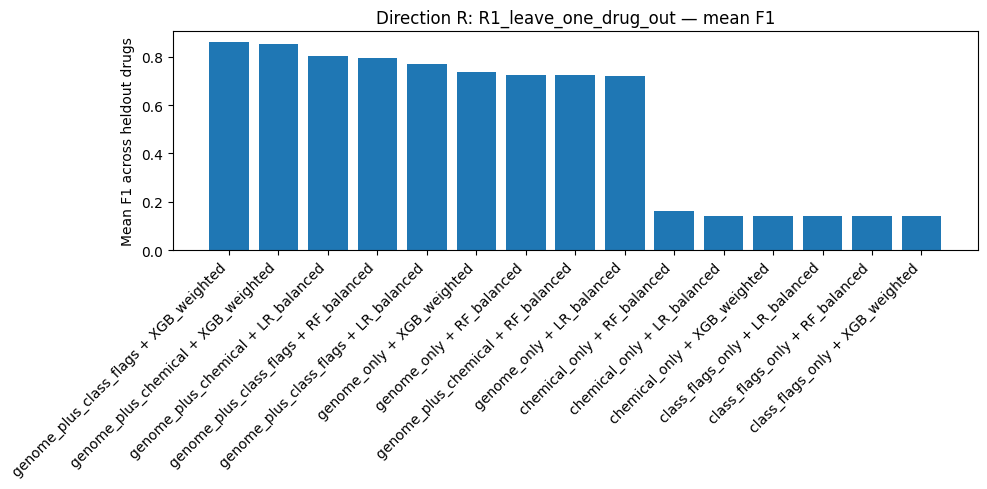

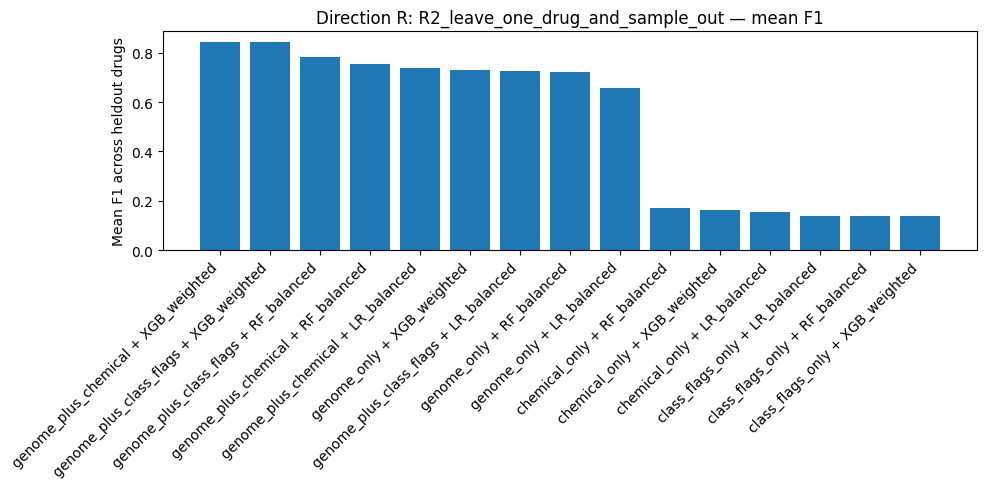

In [13]:

# =========================
# 12. So sánh setting trong thuốc mới
# =========================

# Tổng hợp trung bình qua heldout drugs để xem setting nào tổng quát tốt nhất.
overall = (
    summary
    .groupby(["protocol", "setting", "model"])[["balanced_accuracy_mean", "f1_mean", "auprc_mean"]]
    .mean()
    .reset_index()
    .sort_values(["protocol", "f1_mean", "balanced_accuracy_mean"], ascending=[True, False, False])
)

overall.to_csv(OUTPUT_DIR / "direction_R_overall_setting_comparison.csv", index=False)
display(overall)

for protocol in overall["protocol"].unique():
    sub = overall[overall["protocol"] == protocol].copy()
    labels = sub["setting"] + " + " + sub["model"]
    plt.figure(figsize=(10, 5))
    plt.bar(labels, sub["f1_mean"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean F1 across heldout drugs")
    plt.title(f"Direction R: {protocol} — mean F1")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"direction_R_{protocol}_mean_f1.png", dpi=200)
    plt.show()


In [14]:

# =========================
# 13. Auto conclusion
# =========================

lines = []
lines.append("# Direction R — Auto conclusion")
lines.append("")
lines.append("## 1. Mục tiêu")
lines.append("Direction R mô phỏng thuốc mới bằng leave-one-drug-out. Train trên 4 thuốc, test trên thuốc còn lại.")
lines.append("")
lines.append("## 2. Best setting theo từng thuốc bị giữ lại")

for _, row in best_df.iterrows():
    lines.append(
        f"- {row['protocol']} | heldout {row['heldout_drug']}: "
        f"best = {row['setting']} + {row['model']}; "
        f"F1 = {row['f1_mean']:.3f}, "
        f"balanced accuracy = {row['balanced_accuracy_mean']:.3f}, "
        f"AUPRC = {row['auprc_mean']:.3f}."
    )

lines.append("")
lines.append("## 3. Diễn giải")
lines.append("- Nếu genome_plus_chemical hoặc genome_plus_class_flags thắng, thông tin thuốc giúp mô hình tổng quát sang thuốc mới.")
lines.append("- Nếu genome_only thắng, chemical descriptors hiện chưa bổ sung nhiều, có thể do chỉ có 5 thuốc.")
lines.append("- Nếu kết quả thấp cho một heldout drug, thuốc đó có cơ chế/nhóm thuốc khác biệt hoặc cần thêm thuốc cùng nhóm trong training.")
lines.append("")
lines.append("## 4. Kết luận thực tế")
lines.append("Với dữ liệu hiện tại, Direction R là kiểm tra mô phỏng thuốc mới. Nếu muốn dự đoán thuốc mới thật sự, cần có thêm nhiều kháng sinh hơn để model học được quan hệ giữa cấu trúc thuốc và kiểu gene kháng.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUTPUT_DIR / "AUTO_CONCLUSION_DIRECTION_R.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)


# Direction R — Auto conclusion

## 1. Mục tiêu
Direction R mô phỏng thuốc mới bằng leave-one-drug-out. Train trên 4 thuốc, test trên thuốc còn lại.

## 2. Best setting theo từng thuốc bị giữ lại
- R1_leave_one_drug_out | heldout AMP: best = genome_only + LR_balanced; F1 = 0.855, balanced accuracy = 0.876, AUPRC = 0.845.
- R1_leave_one_drug_out | heldout AUG: best = genome_plus_class_flags + RF_balanced; F1 = 0.888, balanced accuracy = 0.971, AUPRC = 0.959.
- R1_leave_one_drug_out | heldout AXO: best = genome_plus_class_flags + XGB_weighted; F1 = 0.971, balanced accuracy = 0.972, AUPRC = 0.975.
- R1_leave_one_drug_out | heldout CHL: best = genome_plus_chemical + LR_balanced; F1 = 0.754, balanced accuracy = 0.900, AUPRC = 0.650.
- R1_leave_one_drug_out | heldout FOX: best = genome_plus_class_flags + XGB_weighted; F1 = 0.944, balanced accuracy = 0.970, AUPRC = 0.966.
- R2_leave_one_drug_and_sample_out | heldout AMP: best = genome_plus_chemical + RF_balanced; F1 = 0.820, balanced accuracy

In [15]:

# =========================
# 14. Zip outputs
# =========================

zip_path = BASE_DIR / "salmonella_direction_R_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("Đã lưu output:", OUTPUT_DIR)
print("Zip:", zip_path)

# Nếu muốn tải về máy:
# from google.colab import files
# files.download(str(zip_path))


Đã lưu output: /content/salmonella_direction_R_leave_one_drug_out/outputs
Zip: /content/salmonella_direction_R_leave_one_drug_out/salmonella_direction_R_outputs.zip
